In [ ]:
# Digital Payment Fraud Detection using Data Mining Techniques

# ---------------- IMPORTING MODULES ----------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
# ─────────────────────────────────────────
# DATA LOADING
# ─────────────────────────────────────────

#df = pd.read_csv('/content/drive/MyDrive/Online_Payments_Dataset.csv')
df = pd.read_csv('Online_Payments_Dataset.csv')
print("Data set has been loaded\n")
# Keeping original copy for graphs
original_data = df.copy()

print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())

Data set has been loaded

Dataset Shape: (1048575, 11)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1048575 non-null  int64  
 1   type            1048575 non-null  str    
 2   amount          1048575 non-null  float64
 3   nameOrig        1048575 non-null  str    
 4   oldbalanceOrg   1048575 non-null  float64
 5   newbalanceOrig  1048575 non-null  float64
 6   nameDest        1048575 non-null  str    
 7   oldbalanceDest  1048575 non-null  float64
 8   newbalanceDest  1048575 non-null  float64
 9   isFraud         1048575 non-null  int64  
 10  isFlaggedFraud  1048575 non-null  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 116.4 MB
None


In [ ]:
# ─────────────────────────────────────────
# PREPROCESSING
# ─────────────────────────────────────────

print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

df.dropna(inplace=True)

# Encode transaction type
df["type"] = df["type"].map({
    "CASH_IN": 0,
    "CASH_OUT": 1,
    "DEBIT": 2,
    "PAYMENT": 3,
    "TRANSFER": 4
})

# Drop unnecessary columns
df.drop(columns=["nameOrig", "nameDest"], inplace=True)

print("\nCleaned Dataset Shape:", df.shape)


Missing Values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate Rows: 0

Cleaned Dataset Shape: (1048575, 9)


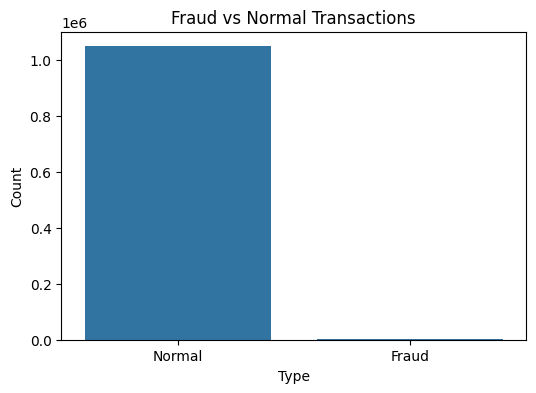

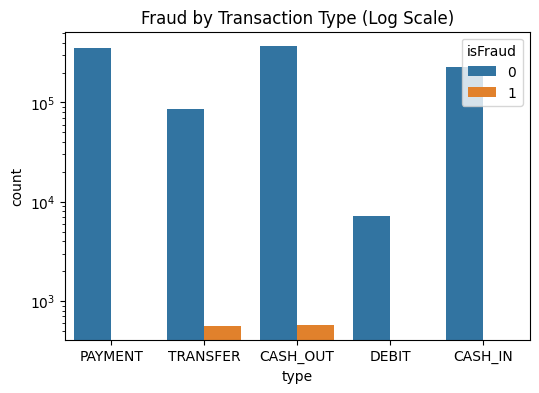

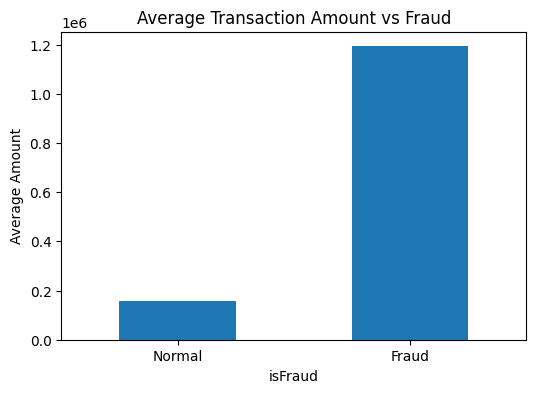

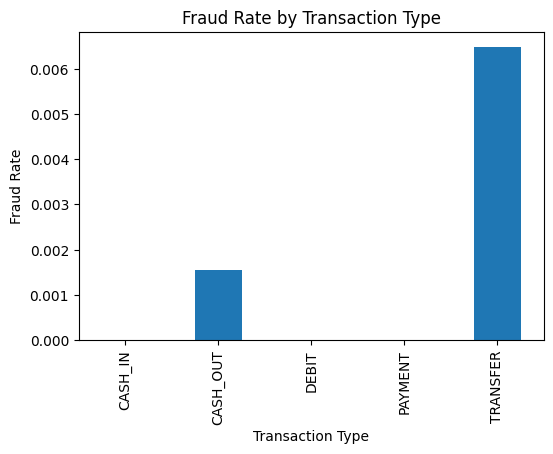

In [ ]:
# ─────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────

# a) Fraud vs Normal
plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Normal Transactions")
plt.xticks([0,1], ["Normal", "Fraud"])
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

# b) Fraud Count by Transaction Type (USE ORIGINAL DATA)
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=original_data, hue='isFraud')
plt.yscale('log')
plt.title("Fraud by Transaction Type (Log Scale)")
plt.show()


# c) Average Amount vs Fraud
avg_amount = df.groupby('isFraud')['amount'].mean()

plt.figure(figsize=(6,4))
avg_amount.plot(kind='bar')
plt.title("Average Transaction Amount vs Fraud")
plt.xticks([0,1], ["Normal", "Fraud"], rotation=0)
plt.ylabel("Average Amount")
plt.show()


# d) Fraud Rate by Transaction Type (SAFE FIX)
fraud_rate = original_data.groupby('type')['isFraud'].mean()

plt.figure(figsize=(6,4))
fraud_rate.plot(kind='bar')
plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.show()

In [ ]:
# ─────────────────────────────────────────
# INSIGHTS
# ─────────────────────────────────────────

print("\n--- Fraud Value Counts ---")
print(df["isFraud"].value_counts())

print("\n--- Fraud Count by Transaction Type ---")
print(original_data.groupby("type")["isFraud"].sum())

print("\n--- Fraud Rate by Transaction Type ---")
print(original_data.groupby("type")["isFraud"].mean())

print("\n--- Transaction Amount Summary ---")
print(df["amount"].describe())

print("\n--- Average Amount (Fraud vs Normal) ---")
print(df.groupby("isFraud")["amount"].mean())


--- Fraud Value Counts ---
isFraud
0    1047433
1       1142
Name: count, dtype: int64

--- Fraud Count by Transaction Type ---
type
CASH_IN       0
CASH_OUT    578
DEBIT         0
PAYMENT       0
TRANSFER    564
Name: isFraud, dtype: int64

--- Fraud Rate by Transaction Type ---
type
CASH_IN     0.000000
CASH_OUT    0.001547
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.006501
Name: isFraud, dtype: float64

--- Transaction Amount Summary ---
count    1.048575e+06
mean     1.586670e+05
std      2.649409e+05
min      1.000000e-01
25%      1.214907e+04
50%      7.634333e+04
75%      2.137619e+05
max      1.000000e+07
Name: amount, dtype: float64

--- Average Amount (Fraud vs Normal) ---
isFraud
0    1.575397e+05
1    1.192629e+06
Name: amount, dtype: float64


In [ ]:
# ---------------- FEATURE ENGINEERING ----------------

df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']
df['is_full_transfer'] = (df['amount'] == df['oldbalanceOrg']).astype(int)
df['zero_dest'] = (df['oldbalanceDest'] == 0).astype(int)

In [ ]:
# ─────────────────────────────────────────
# TRAIN TEST SPLIT
# ─────────────────────────────────────────

# Drop the original label column before modeling
#df.drop(columns=["type_label"], inplace=True)

X = df.drop(columns=["isFraud"])
y = df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

#Scaling for K-Means Clustering
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training Shape: (838860, 12)
Testing Shape: (209715, 12)


In [ ]:
# ---------------- MODELS WITH CLASS IMBALANCE HANDLING ----------------

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Decision Tree
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier(class_weight='balanced', n_estimators=50, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)



In [ ]:

# ─────────────────────────────────────────
# MODEL
# ─────────────────────────────────────────

# --- Decision Tree ---
print("\n========== Decision Tree Classifier ==========")

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))


# --- Logistic Regression ---
print("\n========== Logistic Regression ==========")

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

# --- Random Forest ---
print("\n========== Random Forest ==========")

rf_model = RandomForestClassifier(n_estimators=50, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

# --- KNN ---
print("\n========== KNN ==========")

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, knn_pred))

print("\nClassification Report:")
print(classification_report(y_test, knn_pred))


========== Decision Tree Classifier ==========

Confusion Matrix:
[[209486      5]
 [     6    218]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    209491
           1       0.98      0.97      0.98       224

    accuracy                           1.00    209715
   macro avg       0.99      0.99      0.99    209715
weighted avg       1.00      1.00      1.00    209715


========== Logistic Regression ==========

Confusion Matrix:
[[209491      0]
 [    11    213]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    209491
           1       1.00      0.95      0.97       224

    accuracy                           1.00    209715
   macro avg       1.00      0.98      0.99    209715
weighted avg       1.00      1.00      1.00    209715


========== Random Forest ==========

Confusion Matrix:
[[209491      0]
 [     6    218]]

Classif

In [ ]:
# ─────────────────────────────────────────
# MODEL COMPARISION
# ─────────────────────────────────────────

print("Model Accuracy Comparison:")
print("\nDecision Tree:", accuracy_score(y_test, dt_pred))
print("\nLogistic Regression:", accuracy_score(y_test, lr_pred))
print("\nRandom Forest:", accuracy_score(y_test, rf_pred))
print("\nKNN:", accuracy_score(y_test, knn_pred))

Model Accuracy Comparison:

Decision Tree: 0.9999475478625754

Logistic Regression: 0.9999475478625754

Random Forest: 0.999971389743223

KNN: 0.999971389743223


In [ ]:
# ─────────────────────────────────────────
# FINAL ANALYSIS
# ─────────────────────────────────────────

#Fraud Percentage
print("\nFraud Percentage:")
print(df['isFraud'].value_counts(normalize=True) * 100)

import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(6,4))

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()


Fraud Percentage:
isFraud
0    99.89109
1     0.10891
Name: proportion, dtype: float64


In [ ]:
# ─────────────────────────────────────────
# SAMPLE INPUT TESTING (WITH RANDOM FOREST)
# ─────────────────────────────────────────

import pandas as pd

samples = pd.DataFrame([

    # 1. Normal Transaction
    {
        'step': 1,
        'type': 3,  # PAYMENT
        'amount': 5000,
        'oldbalanceOrg': 20000,
        'newbalanceOrig': 15000,
        'oldbalanceDest': 100000,
        'newbalanceDest': 105000,
        'isFlaggedFraud': 0
    },

    # 2. Fraud-like
    {
        'step': 1,
        'type': 4,  # TRANSFER
        'amount': 500000,
        'oldbalanceOrg': 600000,
        'newbalanceOrig': 100000,
        'oldbalanceDest': 0,
        'newbalanceDest': 500000,
        'isFlaggedFraud': 0
    },

    # 3. Edge Case
    {
        'step': 1,
        'type': 1,  # CASH_OUT
        'amount': 200000,
        'oldbalanceOrg': 200000,
        'newbalanceOrig': 0,
        'oldbalanceDest': 50000,
        'newbalanceDest': 250000,
        'isFlaggedFraud': 0
    },

    # 4. Strong Fraud Case
    {
        'step': 1,
        'type': 4,  # TRANSFER
        'amount': 10000000,
        'oldbalanceOrg': 10000000,
        'newbalanceOrig': 0,
        'oldbalanceDest': 0,
        'newbalanceDest': 10000000,
        'isFlaggedFraud': 0
    }

])

# Add features
samples['balance_diff_orig'] = samples['oldbalanceOrg'] - samples['newbalanceOrig']
samples['balance_diff_dest'] = samples['newbalanceDest'] - samples['oldbalanceDest']
samples['is_full_transfer'] = (samples['amount'] == samples['oldbalanceOrg']).astype(int)
samples['zero_dest'] = (samples['oldbalanceDest'] == 0).astype(int)

# Ensure correct column order
samples = samples[X.columns]
rf_pred = rf_model.predict(samples)
print("\nPredictions (0 = Normal, 1 = Fraud):\n", rf_pred)
#Probabilty Prediction using Random Forest

rf_probs = rf_model.predict_proba(samples)[:, 1]
print("\nFraud Probabilities (Random Forest):")

for i, p in enumerate(rf_probs):
    risk = "High Risk" if p > 0.5 else "Low Risk"
    print(f"Sample {i+1}: {p*100:.2f}% → {risk}")


Predictions (0 = Normal, 1 = Fraud):
 [0 0 1 1]

Fraud Probabilities (Random Forest):
Sample 1: 0.00% → Low Risk
Sample 2: 2.00% → Low Risk
Sample 3: 98.00% → High Risk
Sample 4: 96.00% → High Risk


In [ ]:
# ---------------- MANUAL INPUT ----------------

Manual = pd.DataFrame([{
    'step': 1,
    'type': 4,
    'amount': 50000000,
    'oldbalanceOrg': 50000000,
    'newbalanceOrig': 0,
    'oldbalanceDest': 100000,
    'newbalanceDest': 50100000,
    'isFlaggedFraud': 0
}])


Manual['balance_diff_orig'] = Manual['oldbalanceOrg'] - Manual['newbalanceOrig']
Manual['balance_diff_dest'] = Manual['newbalanceDest'] - Manual['oldbalanceDest']
Manual['is_full_transfer'] = (Manual['amount'] == Manual['oldbalanceOrg']).astype(int)
Manual['zero_dest'] = (Manual['oldbalanceDest'] == 0).astype(int)

# Ensure correct column order
manual = Manual[X.columns]

# Prediction
rf_pred = rf_model.predict(manual)

# Probability
rf_probs = rf_model.predict_proba(manual)[:, 1]

print("\nManual Input Result:")

for i in range(len(manual)):
    label = "Fraud" if rf_pred[i] == 1 else "Normal"
    print(f"Prediction = {rf_pred[i]} ({label})")
    print(f"Fraud Probability = {rf_probs[i]*100:.2f}%")


Manual Input Result:
Prediction = 1 (Fraud)
Fraud Probability = 84.00%
